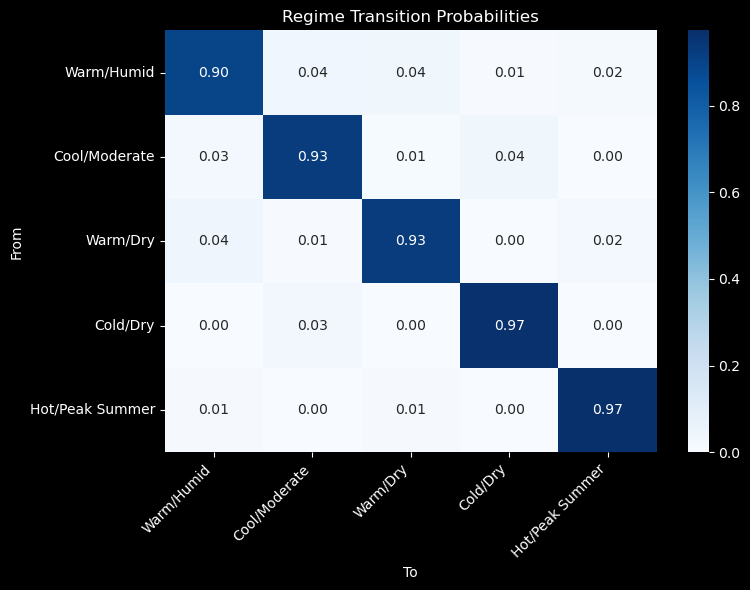

In [2]:
from markovstates.utils import FINAL_FEATURES, Preprocess, FeatMat, hourly_dataframe
from markovstates.models import HMMWeatherModel, WeatherModel
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import seaborn as sns
import matplotlib.pyplot as plt

# heatmap of transition matrix (shows probabilities of moving from one regime to another)

FM = FeatMat(hourly_dataframe, FINAL_FEATURES)
X = FM.construct_feat_mat()

hmm = HMMWeatherModel(n_components=5, covar_type='diag', n_restarts=50)
hmm.load("/Users/philipalexopoulos/markovstates/models/hmm_final.pkl")
transmat = hmm.transition_mat()

regime_labels = [
    "Warm/Humid",
    "Cool/Moderate", 
    "Warm/Dry",
    "Cold/Dry",
    "Hot/Peak Summer"
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    transmat,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=regime_labels,
    yticklabels=regime_labels,
    ax=ax
)
ax.set_title("Regime Transition Probabilities")
ax.set_xlabel("To")
ax.set_ylabel("From")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

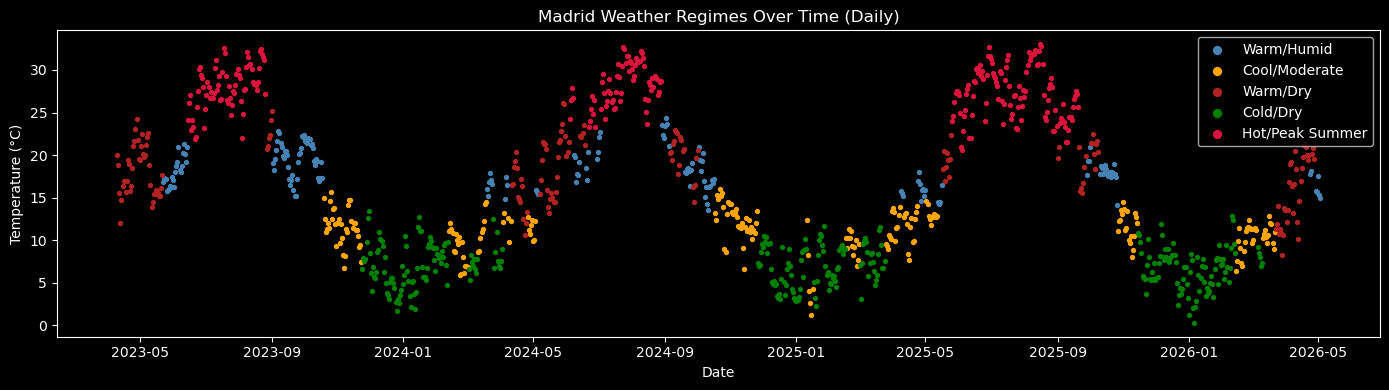

In [3]:
# Regime color coded time series showing different regime states over time

import matplotlib.patches as mpatches

# build daily df with regime labels
pp = Preprocess(hourly_dataframe)
daily = pp.resample()
daily["regime"] = hmm.predict(X)

regime_names = {
    0: "Warm/Humid",
    1: "Cool/Moderate",
    2: "Warm/Dry",
    3: "Cold/Dry",
    4: "Hot/Peak Summer"
}
daily["regime_name"] = daily["regime"].map(regime_names)

# plot
colors = {0: 'steelblue', 1: 'orange', 2: 'firebrick', 3: 'green', 4: 'crimson'}

fig, ax = plt.subplots(figsize=(14, 4))

for regime, group in daily.groupby("regime"):
    ax.scatter(
        group.index,
        group["temperature_2m"],
        c=colors[regime],
        s=8,
        label=regime_names[regime]
    )

ax.set_title("Madrid Weather Regimes Over Time (Daily)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Date")
plt.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.show()